# Однослойный перцептрон
Демонстрация с бесконечностью

In [149]:
import numpy as np

# Функция активации нейрона в выходном слое и ее производная
def sigmoid(x):
    return 1 / (1 + np.exp(-x))
def dsigmoid(y):
    return y * (1 - y)

# Функция активации нейронов во внутреннем слое и ее производная
def tanh(x):
    return np.tanh(x)
def dtanh(y):
    return 1 - y * y

In [151]:
from matplotlib import pyplot as plt

class Perceptron:
    def __init__(self, X, Y, hidden_size):
        
        # Пусть n - количество признаков, m - количество объектов, k - размерность результирующего вектора
        # Тогда X = X(n * m), Y = Y(k, m)
        assert X.shape[1] == Y.shape[1]
        self.X = X
        self.Y = Y
        self.m = X.shape[1]
        
        # Инициализируем матрицы весов рандомными числами (W1 - для скрытого слоя, W2 - для выходного, в нем всего 1 нейрон)
        self.W1 = np.random.randn(hidden_size, X.shape[0])
        self.W2 = np.random.randn(Y.shape[0], hidden_size)
        
        # Заполняем свободные векторы нулями
        self.b1 = np.zeros((hidden_size, 1))
        self.b2 = np.zeros((Y.shape[0], 1))
        
        # Здесь будем накапливать значения функции потерь на каждой итерации
        self.ce_loss = []
        self.mse_loss = []
        
    def learn(self, iter_num, learning_rate):
        
        # Итерируемся необходимое количество раз
        for i in range(iter_num):
            
            # Расчет взыешенных сумм каждого из нейронов, применение функций активации
            # Для того, чтобы заменить функции активации, необходимо заменить функцию при вычислении А1/А2
            Z1 = np.dot(self.W1, self.X) + self.b1                                     # (hidden_size, X.shape[1])
            A1 = tanh(Z1)
            Z2 = np.dot(self.W2, A1) + self.b2                                         # (Y.shape[0], X.shape[1] = Y.shape[1])
            A2 = sigmoid(Z2)

            # Среднеквадратичная (MSE) функция потерь
            mse_loss = np.sum((A2 - self.Y) ** 2) / self.m
            
            # Cross entropy функция потерь
            eps = 1e-8
            logprobs = self.Y * np.log(A2 + eps) + (1 - self.Y) * np.log(1 - A2 + eps)
            ce_loss = (-1 / self.m) * np.sum(logprobs)
            
            # Запоминание значения функции потерь и печать на каждой 1000-й итерации
            self.mse_loss.append(mse_loss)
            self.ce_loss.append(ce_loss)
            if i % 1000 == 0: print(f"MSE loss: {mse_loss}, CE loss: {ce_loss}")

            # Алгоритм обратного распространения ошибки
            # Производные высчитываются по правилу производной для сложной функции
            # Оптимизируется среднеквадратичная функция потерь
            # Для оптимизации cross entropy необходимо заменить производную функции потерь по A2 - self.Y
            # Для этого необходимо найти dError/dW
            # При замене функций активации необходимо также заменить соответствующую ей производную
            dA2 = (A2 - self.Y) * dsigmoid(A2)        # dLoss/dA * dSig/dZ2            # (Y.shape[0], Y.shape[1] = X.shape[1])
            dW2 = np.dot(dA2, A1.T)                   # dZ2/dW2                        # (Y.shape[0], hidden_size)
            db2 = np.sum(dA2, axis=1, keepdims=True)                                   # (Y.shape[0], 1)
            dA1 = np.dot(self.W2.T, dA2) * dtanh(A1)  # dA2 * dZ2/dA1 * dTanh/dZ       # (hidden_size, Y.shape[1] = X.shape[1])
            dW1 = np.dot(dA1, self.X.T)               # dZ1/dW                         # (hidden_size, X.shape[0])
            db1 = np.sum(dA1, axis=1, keepdims=True)                                   # (hidden_size, 1)
            
            # Обновление весов методом градиентного спуска
            self.W2 -= learning_rate * dW2
            self.b2 -= learning_rate * db2
            self.W1 -= learning_rate * dW1
            self.b1 -= learning_rate * db1
            
    def predict(self, X):
        # Используем найденные матрицы весов
        A1 = tanh(np.dot(self.W1, X) + self.b1)
        A2 = sigmoid(np.dot(self.W2, A1) + self.b2)
        return (A2[0] > 0.5).astype(int)
    
    def plot(self):
        plt.figure(figsize=(10,3))
        plt.subplot(1, 2, 1)
        plt.ylabel('MSE loss')
        plt.xlabel('Iterations')
        plt.plot(self.mse_loss)
        plt.subplot(1, 2, 2)
        plt.ylabel('CE loss')
        plt.xlabel('Iterations')
        plt.plot(self.ce_loss)

## Разделение бесконечности

In [154]:
def create_infinity(m, noise=0.1):
    D = 2
    N = m//2 # количество точек для каждого класса
    X = np.zeros((m, D))
    Y = np.zeros((m, 1), dtype='uint8')

    # Class 0 (top part))
    t = np. linspace(0, 1, N)
    x_top = t*2 - 1 # scale to [-1, 1]
    y_top = np.sin(2*np.pi*t) + np.random.randn(N)*noise

    X[0:N] = np.c_[x_top, y_top]
    Y[0:N] = 0

    # Class 1 (bottom part)
    x_bottom = t*2 - 1  # scale to [-1, 1]
    y_bottom = -np.sin(2*np.pi*t) + np.random.randn(N)*noise

    X[N:m] = np.c_[x_bottom, y_bottom]
    Y[N:m] = 1

    return X.T, Y.T

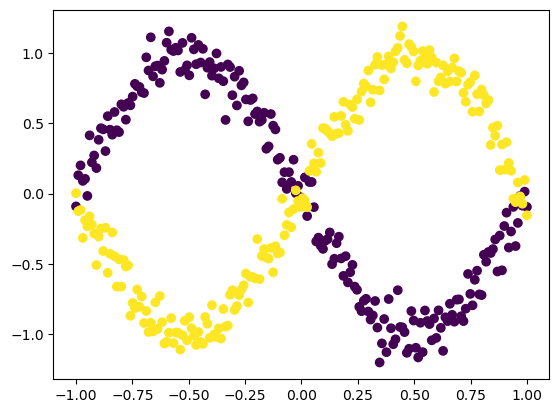

In [156]:
X, Y = create_infinity(400)
plt.scatter(X[0, :], X[1, :], c=Y)

In [158]:
# Строим разделяющую  прямую, показывающую результат обучения нейросети
def plot_division(perceptron):
    x_min, x_max = X[0, :].min() - 1, X[0, :].max() + 1
    y_min, y_max = X[1, :].min() - 1, X[1, :].max() + 1
    h = 0.01
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = perceptron.predict(np.c_[xx.ravel(), yy.ravel()].T)
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral)
    plt.ylabel('x2')
    plt.xlabel('x1')
    plt.scatter(X[0, :], X[1, :], c=Y, cmap=plt.cm.Spectral);

### Один нейрон

In [161]:
perceptron = Perceptron(X, Y, 1)
perceptron.learn(10000, 0.01)

MSE loss: 0.25031885604768506, CE loss: 0.6937854470791831
MSE loss: 0.1949524858622484, CE loss: 0.5539390815171333
MSE loss: 0.19373784290721852, CE loss: 0.5490210881825285
MSE loss: 0.19329156508936238, CE loss: 0.5473010955914345
MSE loss: 0.19305391559338317, CE loss: 0.5464523284527666
MSE loss: 0.19290485520787848, CE loss: 0.5459762611397051
MSE loss: 0.19280171356632017, CE loss: 0.5456944205925375
MSE loss: 0.19272542563823855, CE loss: 0.5455250834821821
MSE loss: 0.19266623265026514, CE loss: 0.5454249841221682
MSE loss: 0.19261864652808441, CE loss: 0.5453690983161912


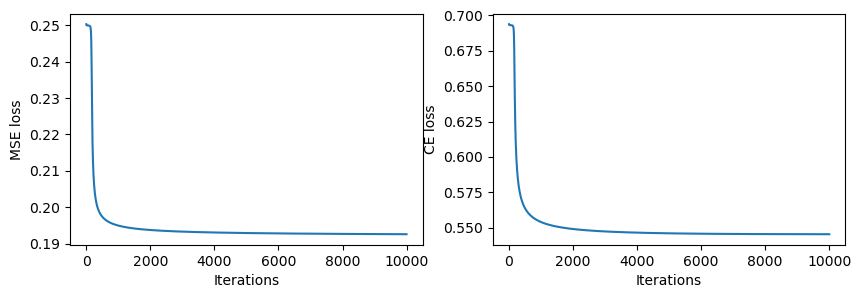

In [162]:
perceptron.plot()

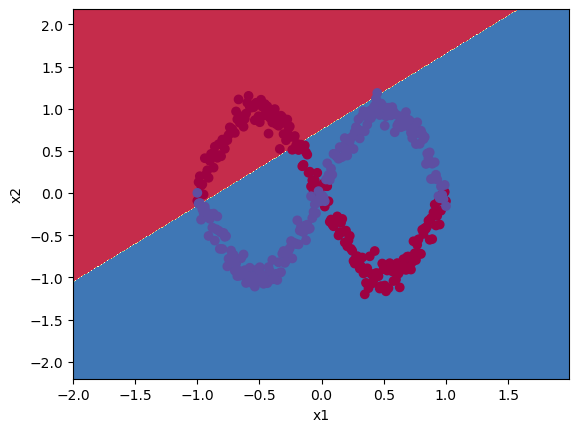

In [165]:
# Строим разделяющую  прямую, показывающую результат обучения нейросети
plot_division(perceptron)

In [209]:
pred = perceptron.predict(X)
pred = np.array(pred)
Y = np.array(Y)

mask = pred == Y
errors = np.sum(~mask) 
print(errors)

124


### Четыре нейрона

In [211]:
perceptron = Perceptron(X, Y, 4)
perceptron.learn(10000, 0.01)

MSE loss: 0.295693168568939, CE loss: 0.798202758061035
MSE loss: 0.027553921177760805, CE loss: 0.10024183409622774
MSE loss: 0.025100241079397467, CE loss: 0.08884082486396842
MSE loss: 0.02386843089721873, CE loss: 0.08325849816662871
MSE loss: 0.023056824587159203, CE loss: 0.07969202084661009
MSE loss: 0.0224598014229434, CE loss: 0.07712518695650877
MSE loss: 0.021991858272725234, CE loss: 0.07515046718634959
MSE loss: 0.021609735331377732, CE loss: 0.07356155350207799
MSE loss: 0.021289603941807077, CE loss: 0.07223700374120243
MSE loss: 0.021017329763564182, CE loss: 0.07110221829113864


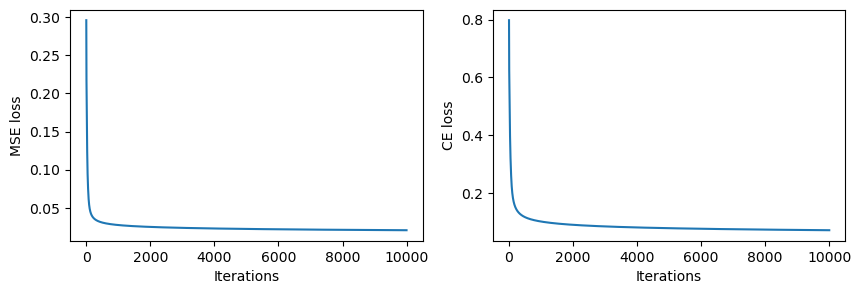

In [212]:
perceptron.plot()

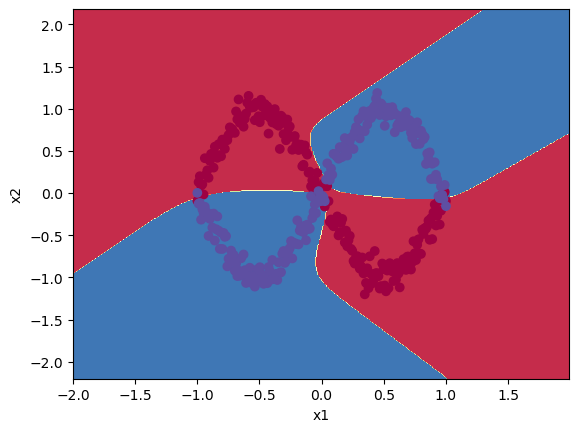

In [213]:
plot_division(perceptron)

In [217]:
pred = perceptron.predict(X)
pred = np.array(pred)
Y = np.array(Y)

mask = pred == Y
errors = np.sum(~mask) 
print(errors)

13


### много нейронов - стало ли лучше?

In [219]:
perceptron = Perceptron(X, Y, 100)
perceptron.learn(10000, 0.01)

MSE loss: 0.4171066468689634, CE loss: 1.5868343033286367
MSE loss: 0.02376659159075137, CE loss: 0.07632995615325398
MSE loss: 0.022045306730894644, CE loss: 0.07009584433569745
MSE loss: 0.02106098152501483, CE loss: 0.06656178364582804
MSE loss: 0.02040169224467795, CE loss: 0.06418528193782011
MSE loss: 0.019912532816873482, CE loss: 0.062463211604106145
MSE loss: 0.019524876442606455, CE loss: 0.061134153306593345
MSE loss: 0.019205569621919487, CE loss: 0.0600224180465877
MSE loss: 0.01893072543343598, CE loss: 0.059051078977296556
MSE loss: 0.01868268173401379, CE loss: 0.05818218773790352


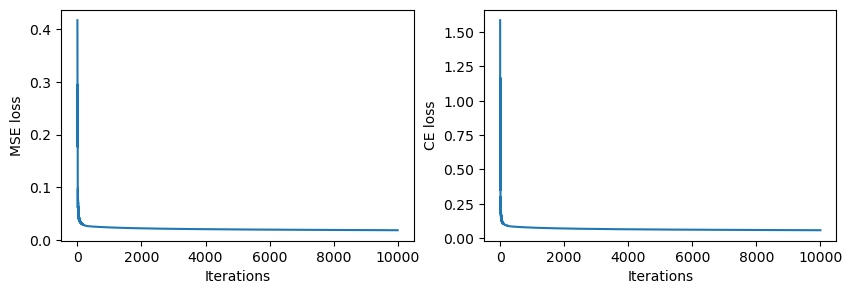

In [220]:
perceptron.plot()

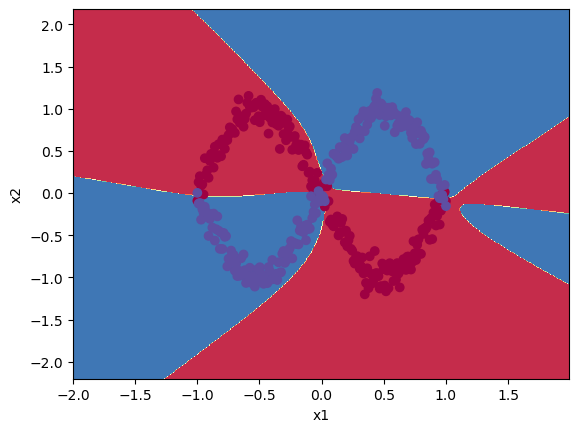

In [221]:
plot_division(perceptron)

In [223]:
pred = perceptron.predict(X)
pred = np.array(pred)
Y = np.array(Y)

mask = pred == Y
errors = np.sum(~mask) 
print(errors)

12


In [37]:
perceptron = Perceptron(X, Y, 2)
perceptron.learn(10000, 0.01)

MSE loss: 0.2717614187729939, CE loss: 0.7409761435117312
MSE loss: 0.15216305004245861, CE loss: 0.4358027633849104
MSE loss: 0.15083613920000702, CE loss: 0.4303076114102949
MSE loss: 0.15013252914794126, CE loss: 0.4279799391742374
MSE loss: 0.14965232869326603, CE loss: 0.4265575240039686
MSE loss: 0.1492914153350204, CE loss: 0.42554888975349797
MSE loss: 0.1490027225437067, CE loss: 0.42478290905632743
MSE loss: 0.1487619982337292, CE loss: 0.424176388710751
MSE loss: 0.14855542437033276, CE loss: 0.423682197977191
MSE loss: 0.1483744272961651, CE loss: 0.42327181950583737


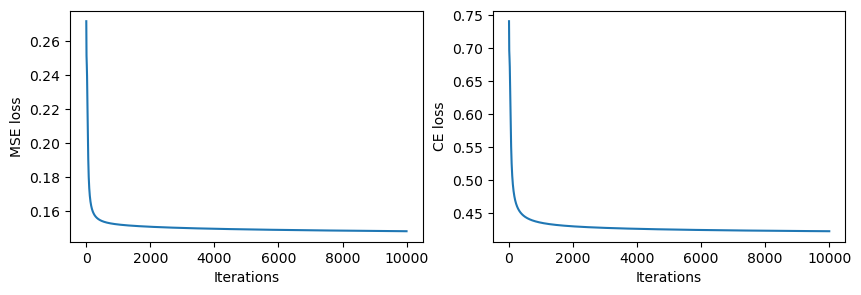

In [38]:
perceptron.plot()

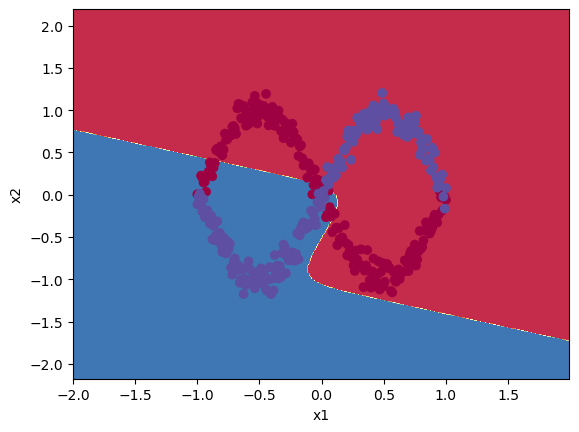

In [39]:
plot_division(perceptron)

In [227]:
perceptron = Perceptron(X, Y, 3)
perceptron.learn(10000, 0.01)

MSE loss: 0.25082477139637294, CE loss: 0.694801191204386
MSE loss: 0.04002029228846288, CE loss: 0.14901474829457673
MSE loss: 0.03676090544467219, CE loss: 0.13101091923935612
MSE loss: 0.03509501239475263, CE loss: 0.12361617922306421
MSE loss: 0.034349833144517394, CE loss: 0.11965589528179571
MSE loss: 0.03382653347657715, CE loss: 0.11689824531368621
MSE loss: 0.03339631342903296, CE loss: 0.11475412712503276
MSE loss: 0.03298629652875961, CE loss: 0.11290869670508474
MSE loss: 0.03258208595710995, CE loss: 0.11126200802637726
MSE loss: 0.03218962491238703, CE loss: 0.1097917921823092


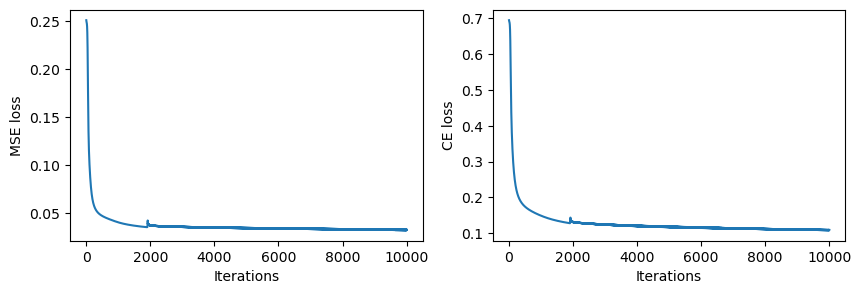

In [228]:
perceptron.plot()

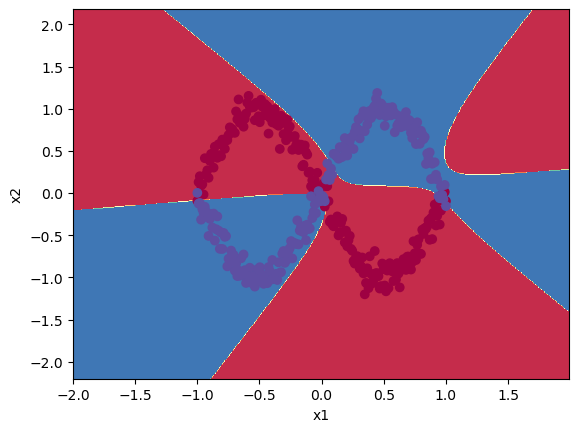

In [231]:
plot_division(perceptron)

In [233]:
pred = perceptron.predict(X)
pred = np.array(pred)
Y = np.array(Y)

mask = pred == Y
errors = np.sum(~mask) 
print(errors)

20


In [235]:
perceptron = Perceptron(X, Y, 8)
perceptron.learn(10000, 0.01)

MSE loss: 0.263875867942715, CE loss: 0.7222627389370374
MSE loss: 0.02668796909703829, CE loss: 0.09556283333244898
MSE loss: 0.023963071336646432, CE loss: 0.08355535504874329
MSE loss: 0.022437688551103598, CE loss: 0.07742269663390833
MSE loss: 0.021390789154558058, CE loss: 0.07332726165357191
MSE loss: 0.02062987429520101, CE loss: 0.07040722715667658
MSE loss: 0.02005157415648059, CE loss: 0.06822863291783733
MSE loss: 0.01959259280038739, CE loss: 0.066509867232527
MSE loss: 0.01921379140057876, CE loss: 0.065077948367731
MSE loss: 0.01889100536919565, CE loss: 0.0638352755230898


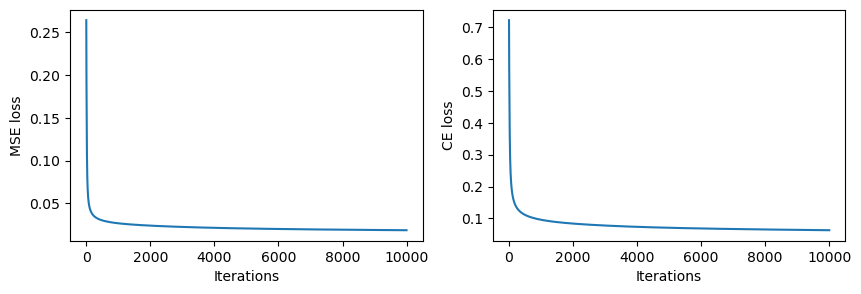

In [236]:
perceptron.plot()

In [241]:
pred = perceptron.predict(X)
pred = np.array(pred)
Y = np.array(Y)

mask = pred == Y
errors = np.sum(~mask) 
print(errors)

13


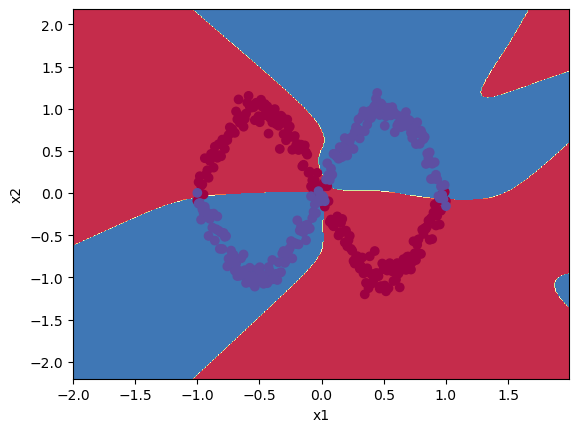

In [237]:
plot_division(perceptron)

In [251]:
perceptron = Perceptron(X, Y, 20)
perceptron.learn(10000, 0.01)

MSE loss: 0.41709870365837615, CE loss: 1.4042542344652469
MSE loss: 0.025230409213655176, CE loss: 0.0886463061666685
MSE loss: 0.022447144730976278, CE loss: 0.07733268608206113
MSE loss: 0.021077182322384848, CE loss: 0.07157091015307133
MSE loss: 0.02022984900061524, CE loss: 0.06792953388966823
MSE loss: 0.01964726584164167, CE loss: 0.06537349050773689
MSE loss: 0.01921516652264192, CE loss: 0.06346132150360392
MSE loss: 0.018867917002100817, CE loss: 0.061947738546198644
MSE loss: 0.018567184774446625, CE loss: 0.06067813523407571
MSE loss: 0.01829205997215972, CE loss: 0.059552497791738164


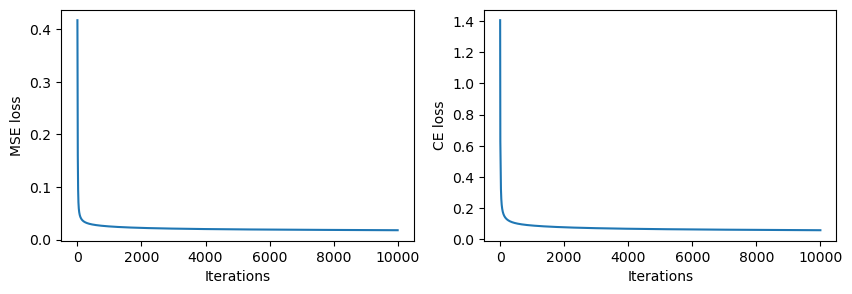

In [252]:
perceptron.plot()

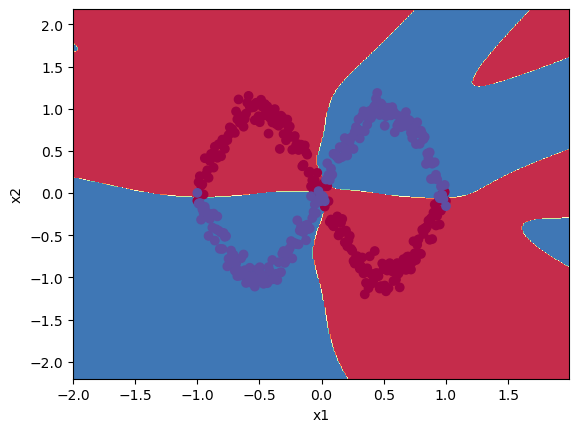

In [253]:
plot_division(perceptron)

In [254]:
pred = perceptron.predict(X)
pred = np.array(pred)
Y = np.array(Y)

mask = pred == Y
errors = np.sum(~mask) 
print(errors)

13
